---
title: earthkit-meteo: vertical
short_title: vertical
---

## Earthkit-meteo: interpolate GRIB from model to height levels

This notebook demonstrates how to interpolate GRIB data from ECMWF model levels to height levels. At the moment, this type of vertical interpolation is only available for array data so we will carry out the computations with the array level interface of earthkit-meteo.

### Getting the data

The input data contains t (temperature), q (specific humidity), u, v and w fields on model levels 60-137 for one time step. The lnsp (logarithm of surface pressure) and zs (surface geopotential) fields are also available. 

In [1]:
import numpy as np
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.meteo.vertical.array as vertical

fl = ekd.from_source("sample", "xs_ml_wind_orog.grib").to_fieldlist()
len(fl)

392

In [2]:
fl[:2].ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2022-04-30,2022-04-29 12:00:00,0 days 12:00:00,60,hybrid,0,regular_ll
1,q,2022-04-30,2022-04-29 12:00:00,0 days 12:00:00,60,hybrid,0,regular_ll


### Preparing the data

First, we select the lnsp, t, q and zs fields and extract the values from them as numpy arrays. The t and q fields must be sorted in ascending order with regards to the model levels for the computations.

In [3]:
lnsp = fl.sel({"parameter.variable": "lnsp"})[0]
t = fl.sel({"parameter.variable": "t"}).order_by({"vertical.level": "ascending"})
q = fl.sel({"parameter.variable": "q"}).order_by({"vertical.level": "ascending"})
zs = fl.sel({"parameter.variable": "z", "vertical.level": 1})[0]

sp_vals = np.exp(lnsp.values) # surface pressure
t_vals = t.values
q_vals = q.values
zs_vals = zs .values

Next, we get the hybrid level definitions using hybrid_level_parameters().

In [4]:
A, B = vertical.hybrid_level_parameters(137)

### Computations

We carry out the computations in 2 steps: 
- first, we compute the height on model levels with height_on_hybrid_level()
- next, we interpolate the fields to the target heights with interpolate_monotonic()

In [5]:
# compute geometric height above the ground on model levels using numpy arrays
h  = vertical.height_on_hybrid_levels(t_vals, q_vals, zs_vals, A, B, sp_vals, 
                             h_type="geometric", h_reference="ground")

In [6]:
# interpolate t to geometric height (m) levels above the ground
target_h=[1000., 5000.] 

res = vertical.interpolate_monotonic(t_vals, h, target_h, interpolation="linear")

# the result is numpy array
res.shape

(2, 4131)

### Writing the results into a fieldlist

Finally, we create a new fieldlist from the results and set the medatadata correctly in it.

In [7]:
t_res = []
for hv, rv in zip(target_h, res):
    f = t[0].set({"vertical.level": hv, "vertical.level_type": "height_above_ground_level", "values": rv})
    t_res.append(f)
t_res = ekd.create_fieldlist(t_res)
t_res.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2022-04-30,2022-04-29 12:00:00,0 days 12:00:00,1000.0,height_above_ground_level,0,regular_ll
1,t,2022-04-30,2022-04-29 12:00:00,0 days 12:00:00,5000.0,height_above_ground_level,0,regular_ll


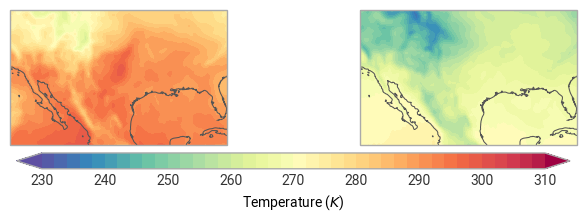

In [8]:
# chek the results visually
ekp.quickplot(t_res)

### Interpolating other fields

In other to interpolate other vertical fields in pur data we only need to call interpolate_monotonic() since we can reuse the "h" fields. The code below uses a helper method and interpolate the u and v wind component.

In [9]:
def _comp(param):  
    fl_param = fl.sel({"parameter.variable": param}).order_by({"vertical.level": "ascending"})
    vals = fl_param.values
    
    res = vertical.interpolate_monotonic(vals, h, target_h, interpolation="linear")
    
    param_res = []
    for hv, rv in zip(target_h, res):
        f = fl_param[0].set({"vertical.level": hv, "vertical.level_type": "height_above_ground_level", "values": rv})
        param_res.append(f)
    param_res = ekd.create_fieldlist(param_res)
    return param_res

u_res = _comp("u")
v_res = _comp("v")

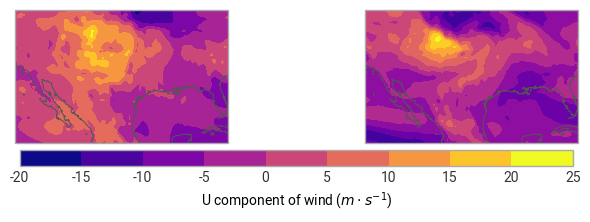

In [10]:
ekp.geo.plot(u_res)

IndexError: index 50 is out of bounds for axis 0 with size 2

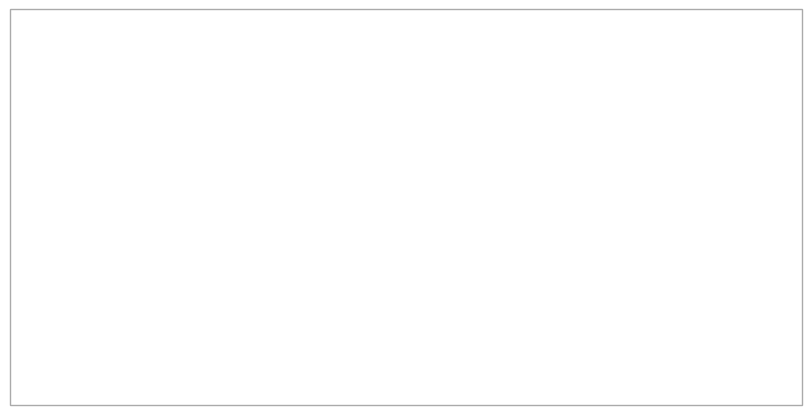

In [11]:
# Create a map of the region around the UK
chart = ekp.Map(domain="global")

# Pass U and V components separately
chart.quiver(u=u_res, v=v_res)

# Add map features
chart.coastlines()
chart.land()
chart.gridlines()

# Show the plot
chart.show()

In [ ]:
import earthkit.data as ekd
import earthkit.plots as ekp

fl = ekd.from_source("sample", "xs_ml_wind_orog.grib").to_fieldlist()

u_res = fl.sel({"parameter.variable": "u", "vertical.level": 100})
v_res = fl.sel({"parameter.variable": "v", "vertical.level": 100})

# Create a map of the region around the UK
chart = ekp.Map(domain="global")

# Pass U and V components separately
chart.quiver(u=u_res, v=v_res)

# Add map features
chart.coastlines()
chart.land()
chart.gridlines()

# Show the plot
chart.show()